In [ ]:
# Implementing a simple linear regression

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [ ]:
df = pd.read_csv('/content/height-weight.csv')

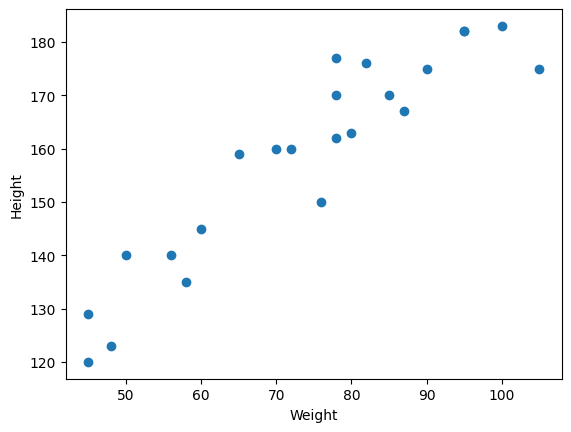

In [ ]:
# scatter plot
plt.scatter(df['Weight'],df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')
plt.show()

In [ ]:
## Finding correlation
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


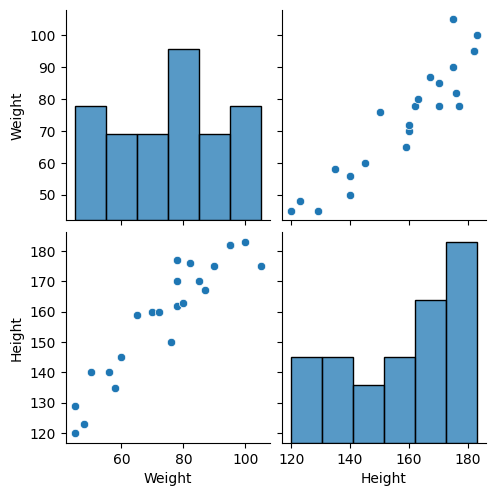

In [ ]:
# Pretty strong relation
## Seaborn for visualiztion
import seaborn as sns
sns.pairplot(df)

In [ ]:
## Independent and dependent features

X = df[['Weight']] # independent feature should be dataframe or two dimensional array
np.array(X)

y = df['Height'] # this value can be in series or 1-D array form
np.array(y)



array([120, 135, 123, 145, 160, 162, 163, 175, 182, 170, 176, 182, 175,
       183, 170, 177, 140, 159, 150, 167, 129, 140, 160])

In [ ]:
## Train-Test split
from sklearn.model_selection import train_test_split


X_train,X_test,y_train,y_test = train_test_split(X,y,
                                  test_size=0.25
                                  ,random_state=42) # random state



In [ ]:
## Standardization
## kura k ho bhaen kun le kati effect garyo bhanne kura size ma depend huna vayena

from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler() # z = (Xi- mu) / n
X_train = scaler.fit_transform(X_train)


In [ ]:
X_test = scaler.transform(X_test)


In [ ]:
## Apply Simpler linear regression
## training data should have 2d array.

from sklearn.linear_model import LinearRegression

regression = LinearRegression(n_jobs=-1)
regression.fit(X_train,y_train)



LinearRegression(n_jobs=-1)

In [ ]:
print("Coefficient or slope",regression.coef_)
print("Intercept:",regression.intercept_)

Coefficient or slope [17.2982057]
Intercept: 156.47058823529412


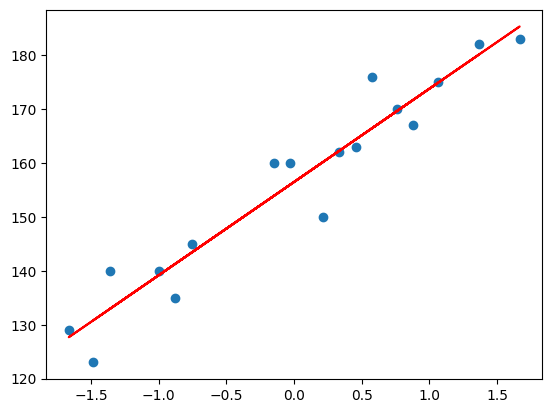

In [ ]:
## plot training data plot best fit line
plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train),color='red')

In [ ]:
y_pred = regression.predict(X_test)
y_test_pred = regression.predict(X_test)

print(y_test_pred)  # model's predictions

print(y_test)       # actual answers


[162.26499721 162.26499721 127.68347133 180.07972266 148.64197186
 190.55897293]
15    177
9     170
0     120
8     182
17    159
12    175
Name: Height, dtype: int64


In [ ]:
### Perfomance matrix
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

mse = mean_squared_error(y_test, y_test_pred)
mae = mean_absolute_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)

print("MSE:", mse)
print("R²:", r2)
print('MAE',mae)

MSE: 114.84069295228699
R²: 0.7360826717981276
MAE 9.66512588679501


In [ ]:
from sklearn.metrics import r2_score

train_pred = regression.predict(X_train)
test_pred = regression.predict(X_test)

print("Training R²:", r2_score(y_train, train_pred))
print("Test R²:", r2_score(y_test, test_pred))

Training R²: 0.9208287444697436
Test R²: 0.7360826717981276


In [ ]:
## OLS Linear Regression
import statsmodels.api as sm


In [ ]:
model = sm.OLS(y_train,X_train).fit()


In [ ]:
prediction = model.predict(X_test)
print(prediction)

[  5.79440897   5.79440897 -28.78711691  23.60913442  -7.82861638
  34.08838469]


In [ ]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Fri, 25 Sep 2026   Prob (F-statistic):                       0.664
Time:                        01:39:06   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------